# Gravitational Lensing Image Analysis

This notebook analyzes two pictures taken with the same setup:

- **Ring picture** (`RING_IMAGE_PATH`): one ring. The notebook detects the ring, finds the **coordinates of its center**, and measures its **radius / diameter** in actual units.
- **Double-image picture** (`DOUBLE_IMAGES_PATH`): two lensed images (vague lines or blobs). The notebook finds both images, measures the **light intensity of each** and their ratio, and finds the **distance of each image from the ring center** measured in the ring picture.

Steps:

1. **Read in both pictures** (converting JPEG values back to values proportional to light)
2. **Background-subtract** them (using a background frame scaled to each picture's exposure, or an estimate from each picture's border)
3. **Ring picture:** detect the ring and find its center, radius, and diameter
4. **Double-image picture:** intensity of the two images
5. **Distance of each image from the ring center**
6. **Summary**

**Requires:** `numpy`, `matplotlib`, `scikit-image`, `scipy`, `pillow`

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import io, color, feature, transform, segmentation, morphology
from skimage.util import img_as_float32
from scipy import ndimage

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 6)

## Settings

Edit everything in the next cell to match your setup:

- `RING_IMAGE_PATH`: the picture with the ring.
- `DOUBLE_IMAGES_PATH`: the picture with the two lensed images. **The camera and pinhole must not move between the two pictures**, because the image distances are measured from the ring center found in the ring picture.
- `BACKGROUND_PATH`: a background frame taken with the light source blocked, or `None` to estimate the background from each picture's border instead.
- `BACKGROUND_SCALE`: the background frame only matches a picture if it was taken with the same exposure time and ISO. With `"auto"`, the notebook reads both from each file's metadata and scales the background frame by the ratio (exposure time × ISO), which is valid because the values are linear (see `LINEARIZE`). Set a number to scale by hand, or `1` to subtract it as-is.
- `LINEARIZE`: JPEGs store brightness on a curved (gamma) scale, so a pixel value of 0.5 is not half as much light as 1.0. With `LINEARIZE = True` the notebook undoes the standard sRGB curve so pixel values are approximately proportional to light. **Keep this on.** It does not affect ring geometry.
- `PIXEL_SCALE`: how many real-world units one pixel spans. Because there is **no lens** on the camera, light falls directly onto the sensor, so the scale is just the sensor's pixel pitch: sensor width / number of pixels across (Nikon Z50 II: 23.5 mm / 5568 px ≈ 4.22 µm per pixel). Sizes are therefore measured **at the sensor plane**. If you save JPEGs at a smaller image size (M or S), set `SENSOR_WIDTH_PX` to that image's pixel width. Don't use crop modes, since a cropped frame no longer spans the full 23.5 mm.

Ring picture:

- `R_MIN_PX`, `R_MAX_PX`: the range of plausible ring radii **in pixels**. `R_MAX_PX = None` searches up to half the image height.

Double-image picture:

- `N_IMAGES`: number of lensed images to measure (2 for this experiment).
- `IMAGE_APERTURES`: `None` to find the images automatically. If automatic detection merges the two images or picks up something else (a reflection, glare), give the regions by hand as a list of `(x, y, radius)` circles in pixels, read off the axes of the plotted picture.

In [11]:
RING_IMAGE_PATH = "example/Img015.jpg"      # picture with the ring
DOUBLE_IMAGES_PATH = "example/Img021.jpg"   # picture with the two lensed images (same camera position!)
BACKGROUND_PATH = "example/Img016.jpg"      # background frame (light source blocked), or None
BACKGROUND_SCALE = "auto"           # "auto" = scale by exposure time x ISO from the metadata, or a number
LINEARIZE = True                    # undo the JPEG gamma curve so pixel values ~ proportional to light

# No lens: light lands directly on the sensor, so one pixel = one sensor pixel pitch.
# Nikon Z50 II sensor: 23.5 x 15.7 mm at 5568 x 3712 pixels.
SENSOR_WIDTH_MM = 23.5
SENSOR_WIDTH_PX = 5568
PIXEL_SCALE = SENSOR_WIDTH_MM / SENSOR_WIDTH_PX   # ~0.00422 mm per pixel (4.22 um)
UNIT = "mm"                         # name of the unit, used in printouts and plots

# --- ring picture ---
R_MIN_PX = 100                      # smallest expected ring radius, in pixels (full resolution)
R_MAX_PX = None                     # largest expected radius in pixels, or None for half the image height

# --- double-image picture ---
N_IMAGES = 2                        # number of lensed images to measure
IMAGE_APERTURES = None              # None = find automatically, or [(x, y, radius), ...] in pixels,
                                    #   e.g. [(1300, 2100, 600), (4400, 1950, 900)]

## 1. Read in both pictures

Each picture is loaded and converted to a grayscale float array in `[0, 1]`. With `LINEARIZE = True`, each color channel is first converted from the JPEG's sRGB curve back to linear light, so grayscale values are proportional to the light that hit the sensor. Linear images look dark on screen, so plots are shown with a display stretch; all measurements use the linear values.

Pixels at the top of the camera's range (saturated) are recorded, because the true brightness there is unknown and intensities that include them are underestimates. The exposure time and ISO are read from each file's metadata.

example/Img015.jpg: 5568 x 3712 px (23.50 x 15.67 mm), exposure 0.03333333333333333 s, ISO 2500, saturated pixels 6.85%
example/Img021.jpg: 5568 x 3712 px (23.50 x 15.67 mm), exposure 0.1 s, ISO 51200, saturated pixels 4.42%


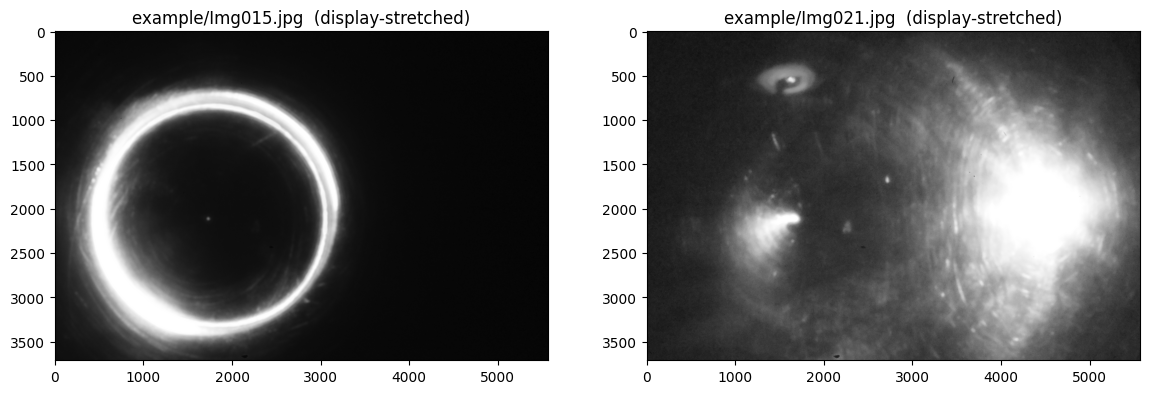

In [12]:
def srgb_to_linear(v):
    """Invert the sRGB transfer curve: encoded value in [0, 1] -> linear light in [0, 1]."""
    return np.where(v <= 0.04045, v / 12.92, ((v + 0.055) / 1.055) ** 2.4)

def load_gray(path):
    """Load an image as grayscale float32 in [0, 1] (linear light if LINEARIZE).
    Returns (gray, saturated) where `saturated` marks pixels clipped in any channel."""
    img = img_as_float32(io.imread(path))
    if img.ndim == 3:
        img = img[..., :3]                            # drop alpha channel if present
        saturated = (img >= 0.995).any(axis=-1)
        if LINEARIZE:
            img = srgb_to_linear(img).astype(np.float32)
        gray = color.rgb2gray(img).astype(np.float32)  # luminance weights assume linear RGB
    else:
        saturated = img >= 0.995
        gray = srgb_to_linear(img).astype(np.float32) if LINEARIZE else img
    return gray, saturated

def exposure_info(path):
    """(exposure time in s, ISO) from the file's EXIF metadata, or (None, None)."""
    exif = Image.open(path).getexif().get_ifd(0x8769)          # Exif sub-IFD
    t, iso = exif.get(0x829A), exif.get(0x8827)                # ExposureTime, ISOSpeedRatings
    return (float(t) if t else None), (int(iso) if iso else None)

def stretch(image):
    """Display-only brightness stretch so linear images are visible on screen."""
    return np.clip(image, 0, None) ** (1 / 2.2) if LINEARIZE else image

ring_gray, ring_saturated = load_gray(RING_IMAGE_PATH)
dbl_gray, dbl_saturated = load_gray(DOUBLE_IMAGES_PATH)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, path, g, sat in [(axes[0], RING_IMAGE_PATH, ring_gray, ring_saturated),
                         (axes[1], DOUBLE_IMAGES_PATH, dbl_gray, dbl_saturated)]:
    t, iso = exposure_info(path)
    print(f"{path}: {g.shape[1]} x {g.shape[0]} px "
          f"({g.shape[1]*PIXEL_SCALE:.2f} x {g.shape[0]*PIXEL_SCALE:.2f} {UNIT}), "
          f"exposure {t} s, ISO {iso}, saturated pixels {100 * sat.mean():.2f}%")
    ax.imshow(stretch(g), cmap='gray')
    ax.set_title(path + ('  (display-stretched)' if LINEARIZE else ''))
plt.show()

## 2. Background subtraction

Two options, chosen automatically based on `BACKGROUND_PATH`:

- **Background frame:** a frame taken with the same setup but the light source blocked is subtracted pixel-by-pixel, after scaling it to each picture's exposure (`BACKGROUND_SCALE`). For example, a background taken at 0.625 s is multiplied by 0.16 before being subtracted from a 0.1 s picture at the same ISO.
- **Border estimate:** otherwise, the background level is estimated as the median of a border strip around the edge of each picture (assuming the ring or images do not reach the edges) and subtracted as a constant.

Negative values after subtraction are clipped to zero. The background-subtracted pictures are used for finding the ring and the images. The intensity measurement additionally subtracts a **local** background around each image, which removes any glow or scattered light that the background frame doesn't account for.

example/Img015.jpg: background = frame 'example/Img016.jpg' x 0.002604 (median after scaling 0.00009)
example/Img021.jpg: background = frame 'example/Img016.jpg' x 0.16 (median after scaling 0.00557)


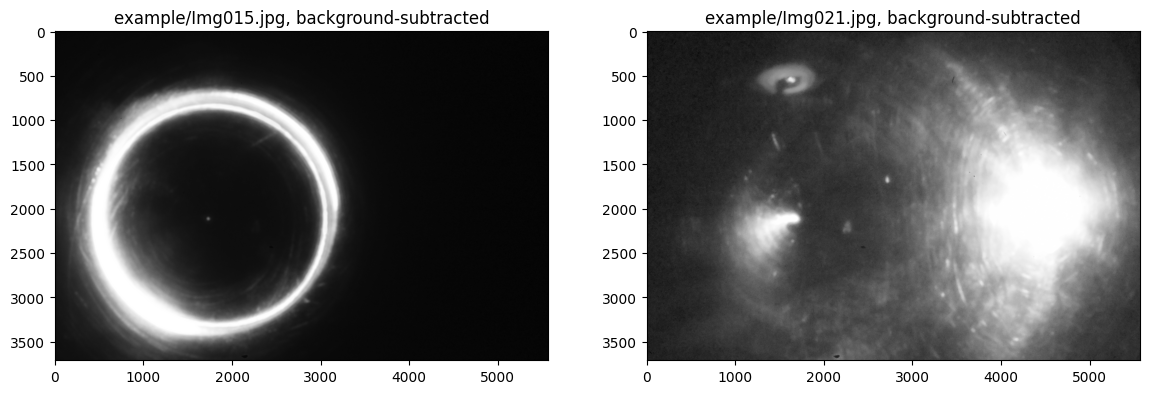

In [13]:
if BACKGROUND_PATH is not None:
    bkg_frame, _ = load_gray(BACKGROUND_PATH)
    t_b, iso_b = exposure_info(BACKGROUND_PATH)

def subtract_background(gray, path):
    """Return (background array, background-subtracted image clipped at 0, description)."""
    if BACKGROUND_PATH is None:
        border = max(10, min(gray.shape) // 20)   # border strip width in pixels
        edge_pixels = np.concatenate([
            gray[:border, :].ravel(),  gray[-border:, :].ravel(),
            gray[:, :border].ravel(),  gray[:, -border:].ravel(),
        ])
        bkg = np.full_like(gray, np.median(edge_pixels))
        desc = f"median of {border}-px border strip = {bkg[0, 0]:.5f}"
    else:
        if bkg_frame.shape != gray.shape:
            raise ValueError(f"Background shape {bkg_frame.shape} does not match image shape {gray.shape}")
        if BACKGROUND_SCALE == "auto":
            t, iso = exposure_info(path)
            if None in (t, iso, t_b, iso_b):
                raise ValueError("Exposure metadata missing; set BACKGROUND_SCALE to a number")
            scale = (t * iso) / (t_b * iso_b)
        else:
            scale = float(BACKGROUND_SCALE)
        if scale != 1 and not LINEARIZE:
            print("WARNING: scaling the background only makes sense with LINEARIZE = True")
        bkg = scale * bkg_frame
        desc = (f"frame '{BACKGROUND_PATH}' x {scale:.4g} "
                f"(median after scaling {np.median(bkg):.5f})")
    return bkg, np.clip(gray - bkg, 0, None), desc

ring_bkg, ring_sub, desc = subtract_background(ring_gray, RING_IMAGE_PATH)
print(f"{RING_IMAGE_PATH}: background = {desc}")
dbl_bkg, dbl_sub, desc = subtract_background(dbl_gray, DOUBLE_IMAGES_PATH)
print(f"{DOUBLE_IMAGES_PATH}: background = {desc}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(stretch(ring_sub), cmap='gray'); axes[0].set_title(f'{RING_IMAGE_PATH}, background-subtracted')
axes[1].imshow(stretch(dbl_sub), cmap='gray'); axes[1].set_title(f'{DOUBLE_IMAGES_PATH}, background-subtracted')
plt.show()

## 3. Ring picture: detect the ring and find its center

Two steps:

1. **Coarse detection** with a circular Hough transform on a Canny edge map of a downscaled copy of the image (a full-resolution Hough transform would need tens of GB of memory). This gives a rough center and radius.
2. **Precise fit along the ring's midline.** From the rough center, the notebook casts 720 rays outward and, along each ray, finds the middle of the bright band: the brightness-weighted average radius of all the light above `MIDLINE_FRAC` (10%) of that ray's peak. Using all of the ring's light, rather than only its brightest part, keeps the midline steady where the ring splits into a thin inner band and a broad outer band. A least-squares circle is fit to these midline points, outliers are rejected, and the process repeats from the new center until it settles.

Because each ray contributes one *position*, regardless of how bright the ring is there, uneven brightness around the ring does not pull the center sideways. Rays where the ring is very faint or missing are ignored.

If detection fails, adjust `R_MIN_PX` / `R_MAX_PX`, or `CANNY_SIGMA` (larger = smoother edges, good for noisy images).

The fitted radius is the radius of the ring's **midline**, in pixels; multiplying by `PIXEL_SCALE` converts it to real units. The quoted uncertainty is statistical (from the scatter of the midline points about the circle); it does not include the ~0.2% uncertainty in the sensor-size spec. Neighboring rays are not fully independent and the ring is not perfectly circular, so treat it as a lower limit; the fit-residual plot shows how far the real ring departs from a circle.

Coarse Hough estimate: center = (1782, 2107) px, radius = 1216 px


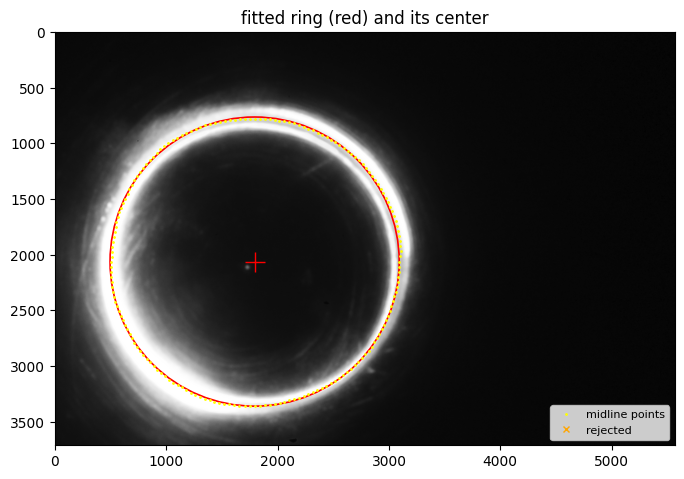

Ring center = (1793.6 ± 0.5, 2061.8 ± 0.5) px  =  (7.5700, 8.7021) mm  (± 0.0022 mm)
Fit used 720 of 720 rays; scatter about the circle = 10.1 px
Ring radius   = 1298.4 ± 0.4 px = 5.4798 ± 0.0016 mm
Ring diameter = 2596.7 ± 0.8 px = 10.9595 ± 0.0032 mm


In [14]:
CANNY_SIGMA = 3          # increase if the edge map (shown below) is noisy
DETECT_MAX_DIM = 600     # coarse Hough detection runs on a copy downscaled to this size (long side)
RIDGE_SMOOTH_PX = 4      # smoothing (pixels) applied before tracing the ring's midline
N_RAYS = 720             # number of rays used to trace the ring
MIN_RAY_FRAC = 0.15      # ignore rays where the ring is fainter than this fraction of the typical ray
MIDLINE_FRAC = 0.1       # midline = brightness-weighted mean radius of light above this fraction of the ray's peak

def fit_circle(x, y):
    """Least-squares (Kasa) circle fit to points; returns (cx, cy, r)."""
    A = np.column_stack([x, y, np.ones_like(x)])
    b = x**2 + y**2
    (a0, a1, a2), *_ = np.linalg.lstsq(A, b, rcond=None)
    cx, cy = a0 / 2, a1 / 2
    return cx, cy, np.sqrt(a2 + cx**2 + cy**2)

def trace_ring(image, cx, cy, r, search):
    """Cast rays from (cx, cy); on each, find the band's midline and half-max edges within
    r*(1 +/- search). Returns per-ray angle, midline x/y, inner/outer half-max radius, peak.
    Parts of a ray outside the image count as dark."""
    theta = np.linspace(0, 2 * np.pi, N_RAYS, endpoint=False)
    radii = np.arange(max(1.0, (1 - search) * r), (1 + search) * r)
    X = cx + np.outer(np.cos(theta), radii)
    Y = cy + np.outer(np.sin(theta), radii)
    prof = ndimage.map_coordinates(image, [Y.ravel(), X.ravel()], order=1,
                                   cval=0.0).reshape(X.shape)
    peak = prof.max(axis=1)
    keep = peak > MIN_RAY_FRAC * np.median(peak)
    theta, prof, peak = theta[keep], prof[keep], peak[keep]
    w = np.clip(prof - MIDLINE_FRAC * peak[:, None], 0, None)
    r_mid = (w * radii).sum(axis=1) / w.sum(axis=1)
    above = prof > peak[:, None] / 2                         # half-max edges of the band
    r_in = radii[np.argmax(above, axis=1)]
    r_out = radii[len(radii) - 1 - np.argmax(above[:, ::-1], axis=1)]
    return theta, cx + r_mid * np.cos(theta), cy + r_mid * np.sin(theta), r_in, r_out, peak

# --- 1. Coarse detection: Hough transform on a small copy of the image ---
s = min(1.0, DETECT_MAX_DIM / max(ring_sub.shape))
small = transform.rescale(stretch(ring_sub), s, anti_aliasing=True) if s < 1 else stretch(ring_sub)
edges_s = feature.canny(small, sigma=CANNY_SIGMA)
r_max_full = R_MAX_PX if R_MAX_PX is not None else min(ring_sub.shape) / 2
test_radii = np.arange(max(3, int(R_MIN_PX * s)), int(np.ceil(r_max_full * s)) + 1)
hough = transform.hough_circle(edges_s, test_radii)
_, cxs, cys, rs = transform.hough_circle_peaks(hough, test_radii, total_num_peaks=1)
cx, cy, r = cxs[0] / s, cys[0] / s, rs[0] / s
print(f"Coarse Hough estimate: center = ({cx:.0f}, {cy:.0f}) px, radius = {r:.0f} px")

# --- 2. Precise fit to the ring's midline, iterated with outlier rejection ---
smooth = ndimage.gaussian_filter(ring_sub, RIDGE_SMOOTH_PX)
search = 0.35
for _ in range(5):
    theta, mx, my, r_in, r_out, peak = trace_ring(smooth, cx, cy, r, search)
    use = np.ones(len(mx), bool)
    for _ in range(3):                                   # 3-sigma clipping
        cx, cy, r = fit_circle(mx[use], my[use])
        resid = np.hypot(mx - cx, my - cy) - r
        use = np.abs(resid) < 3 * resid[use].std()
    search = 0.25

n = use.sum()
rms = resid[use].std()
ring = {
    'cx': cx, 'cy': cy, 'r_px': r,
    'r_in_px': float(np.median(r_in[use])), 'r_out_px': float(np.median(r_out[use])),
    'rms_px': float(rms), 'n_rays': int(n),
    # statistical uncertainties of a circle fit with n points of scatter `rms`
    'err_center_px': float(rms * np.sqrt(2 / n)), 'err_r_px': float(rms / np.sqrt(n)),
}

fig, ax = plt.subplots()
ax.imshow(stretch(ring_gray), cmap='gray')
ax.plot(mx[use][::4], my[use][::4], '.', color='yellow', ms=2, label='midline points')
ax.plot(mx[~use], my[~use], 'x', color='orange', ms=4, label='rejected')
ax.add_patch(plt.Circle((cx, cy), r, fill=False, color='red', lw=1.2))
ax.plot(cx, cy, 'r+', markersize=14)
ax.set_title('fitted ring (red) and its center')
ax.legend(loc='lower right', fontsize=8)
plt.show()

print(f"Ring center = ({cx:.1f} ± {ring['err_center_px']:.1f}, {cy:.1f} ± {ring['err_center_px']:.1f}) px"
      f"  =  ({cx*PIXEL_SCALE:.4f}, {cy*PIXEL_SCALE:.4f}) {UNIT}  (± {ring['err_center_px']*PIXEL_SCALE:.4f} {UNIT})")
print(f"Fit used {n} of {len(mx)} rays; scatter about the circle = {rms:.1f} px")

r_mm, e_mm = ring['r_px'] * PIXEL_SCALE, ring['err_r_px'] * PIXEL_SCALE
print(f"Ring radius   = {ring['r_px']:.1f} ± {ring['err_r_px']:.1f} px = {r_mm:.4f} ± {e_mm:.4f} {UNIT}")
print(f"Ring diameter = {2*ring['r_px']:.1f} ± {2*ring['err_r_px']:.1f} px = {2*r_mm:.4f} ± {2*e_mm:.4f} {UNIT}")

## 4. Double-image picture: intensity of the two lensed images

**Finding the images.** With `IMAGE_APERTURES = None`, the background-subtracted image is smoothed (`BLOB_SMOOTH_PX`) so that vague, patchy light becomes one blob per image, and any remaining smooth background (a gradient or vignetting) is removed by fitting a gentle curved surface to the dark parts of the picture. Each brightness peak that rises above `BLOB_NSIGMA` times the background noise, and stands out from the dip next to it by at least `BLOB_PROMINENCE` of the brightest point, seeds one image. The prominence rule stops patchy texture inside one image from splitting it in two. The `N_IMAGES` regions containing the most light are kept. Each one's **aperture** then extends outward until the smoothed light falls to `EDGE_NSIGMA` times the noise or to `EDGE_FRAC` of that image's own peak, whichever comes first, and grows by `APERTURE_GROW_PX` beyond that. The `EDGE_FRAC` limit matters when glow or scattered light fills the picture and never fades to the noise level; without it, an aperture would spread across the whole glow. If the two images touch, they are split along the faintest line between them. If they still come out as one image, lower `BLOB_PROMINENCE`. Touching images can be separated, but not perfectly: wherever they overlap, some of each image's light falls on the other side of the dividing line. The notebook warns when this happens, because the effect is not included in the uncertainty.

If automatic detection picks up a stray reflection, or the images aren't separated correctly, set `IMAGE_APERTURES` by hand instead. Circles are used as apertures in that case. Make each circle generous: light left outside the aperture is lost.

**Measuring the intensity.** For each image:

- **Local background:** the average (with outliers such as dust or hot pixels discarded) of a band `BKG_WIDTH_PX` wide around the aperture. The band starts `BKG_GAP_PX` away from it, so the images' faint outskirts don't leak into it, and it excludes the region around the other image. It is subtracted from every pixel in the aperture.
- **Total intensity:** the sum of background-corrected pixel values in the aperture. With `LINEARIZE = True` this is proportional to the total light in the image.
- **Centroid:** the intensity-weighted position of the image, which is used for its distance from the ring center in the next section. **Peak** is its brightest pixel.
- **Uncertainty:** two parts, added in quadrature. *Noise* comes from the pixel-to-pixel scatter in the background band. *Aperture size* is how much the intensity changes when the measurement is repeated with a smaller aperture (cut off at twice `EDGE_FRAC`, not grown) and a larger one (half `EDGE_FRAC`, grown twice as much). For real, vague images the aperture-size part is usually the larger of the two. For the **ratio**, the aperture-size part comes from recomputing the ratio with both smaller and both larger apertures. Both images change size together, so the ratio is usually much steadier than either intensity on its own.

Pixel values are in normalized camera units, so the **ratio** of the two intensities is the physically meaningful number. If any pixels in an aperture are **saturated**, that image's intensity is a lower limit; take a shorter exposure.

Note: found 6 candidate regions; measuring the 2 with the most light.


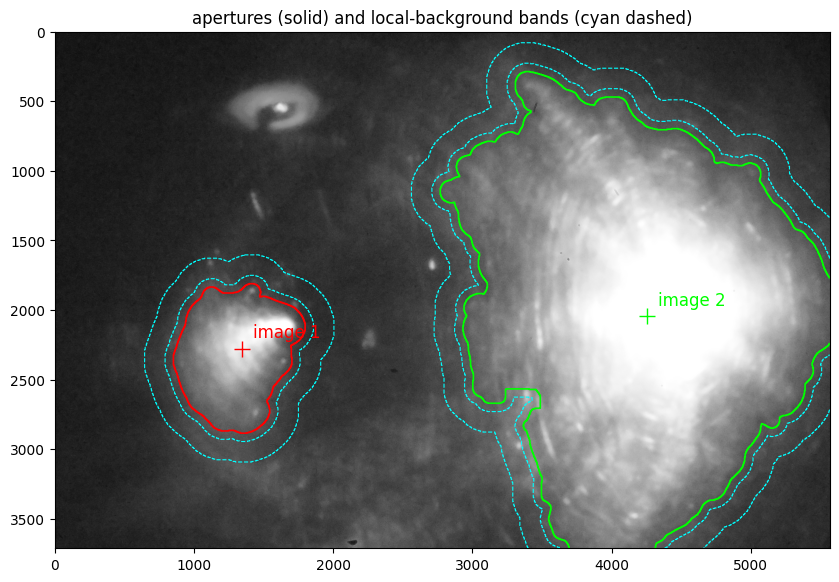

Image 1:  centroid = (1342, 2277) px = (5.663, 9.612) mm
  total intensity = 188655.4 ± 45218.0   (noise ±26.0, aperture size ±45218.0; smaller/larger aperture gives 143437.5 / 221367.3)
  aperture 700513 px, local bkg 0.05508, peak 0.9449
Image 2:  centroid = (4254, 2043) px = (17.956, 8.623) mm
  total intensity = 2536239.2 ± 444429.3   (noise ±133.7, aperture size ±444429.2; smaller/larger aperture gives 2091810.0 / 2745379.5)
  aperture 6211798 px, local bkg 0.07857, peak 0.9214

Intensity ratio (image 1 / image 2) = 0.074 ± 0.006   (smaller/larger apertures give 0.069 / 0.081)


In [15]:
BLOB_SMOOTH_PX = 25      # smoothing (pixels) used only to find the images
BLOB_NSIGMA = 5          # an image must peak above this many times the background noise...
BLOB_MIN_FRAC = 0.05     # ...and above this fraction of the brightest smoothed point
BLOB_PROMINENCE = 0.1    # two touching images are kept separate if the dip between them is at least
                         #   this fraction of the brightest point (lower it if they get merged)
EDGE_NSIGMA = 1.5        # each aperture extends out to where the smoothed light drops to this level...
EDGE_FRAC = 0.1          # ...or to this fraction of that image's own peak, whichever is reached first
                         #   (matters when glow / scattered light fills the picture)
APERTURE_GROW_PX = 40    # then grows by this much more, to include the faintest outskirts
BKG_GAP_PX = 60          # gap between aperture and local-background band (keeps image light out of it)
BKG_WIDTH_PX = 150       # width of the local-background band
FIND_MAX_DIM = 1400      # image finding runs on a copy downscaled to this size (long side)

def upsample_mask(mask_small, shape):
    """Nearest-neighbor upsample of a boolean mask to full resolution."""
    rows = np.minimum((np.arange(shape[0]) * mask_small.shape[0] / shape[0]).astype(int), mask_small.shape[0] - 1)
    cols = np.minimum((np.arange(shape[1]) * mask_small.shape[1] / shape[1]).astype(int), mask_small.shape[1] - 1)
    return mask_small[np.ix_(rows, cols)]

def grow(mask, px):
    """Dilate a boolean mask by about `px` pixels (in that mask's own pixel units)."""
    if px < 1 or not mask.any():
        return mask.copy()
    return ndimage.distance_transform_edt(~mask) <= px

def clipped_mean_std(v, n_sigma=3, n_iter=5):
    """Mean and standard deviation after repeatedly discarding values beyond n_sigma.
    (A mean rather than a median: at low light levels 8-bit JPEG values come in coarse
    steps, and a median snaps to one of them.)"""
    keep = np.ones(v.shape, bool)
    for _ in range(n_iter):
        m, sd = v[keep].mean(), v[keep].std()
        keep = np.abs(v - m) < n_sigma * sd
    return float(v[keep].mean()), float(v[keep].std())

def centroid(vals, ap):
    """Intensity-weighted (x, y) of the background-corrected values `vals` in aperture `ap`."""
    w = np.clip(vals, 0, None)
    ys, xs = np.nonzero(ap)
    return float((w * xs).sum() / w.sum()), float((w * ys).sum() / w.sum())

def measure(ap, band):
    """Background-corrected total intensity in aperture `ap`, with the background from `band`."""
    local_bkg, noise = clipped_mean_std(dbl_gray[band])
    vals = dbl_gray[ap] - local_bkg
    n_ap, n_bg = int(ap.sum()), int(band.sum())
    return {'flux': float(vals.sum()), 'flux_err_stat': noise * np.sqrt(n_ap + n_ap**2 / n_bg),
            'local_bkg': local_bkg, 'peak': float(vals.max()), 'n_pix': n_ap, 'vals': vals}

H, W = dbl_gray.shape
s = min(1.0, FIND_MAX_DIM / max(H, W))

# Each "variant" is one choice of aperture size: nominal, smaller and larger. The nominal one
# gives the result; the spread across them is quoted as the aperture-size uncertainty.
if IMAGE_APERTURES is None:
    # --- find the images automatically on a smoothed, downscaled copy ---
    diff = dbl_gray - dbl_bkg                                    # unclipped, so noise stays symmetric
    small = transform.rescale(diff, s, anti_aliasing=True) if s < 1 else diff
    sm = ndimage.gaussian_filter(small, BLOB_SMOOTH_PX * s)
    # Remove any smooth leftover background (gradients, vignetting): fit a quadratic surface
    # to everything except the bright regions, then subtract it.
    bright = grow(sm > BLOB_MIN_FRAC * sm.max(), 4 * BLOB_SMOOTH_PX * s)
    Y, X = np.mgrid[:sm.shape[0], :sm.shape[1]] / max(sm.shape)
    terms = np.stack([np.ones_like(X), X, Y, X * X, X * Y, Y * Y], axis=-1)
    coef, *_ = np.linalg.lstsq(terms[~bright], sm[~bright], rcond=None)
    sm = sm - terms @ coef
    noise_sm = 1.4826 * np.median(np.abs(sm[~bright] - np.median(sm[~bright])))
    # One seed per brightness peak that stands out by BLOB_PROMINENCE from its surroundings
    # (so patchy texture inside one image doesn't split it) and is bright enough overall.
    detect = sm > max(BLOB_NSIGMA * noise_sm, BLOB_MIN_FRAC * sm.max())
    seeds, n_found = ndimage.label(morphology.h_maxima(sm, BLOB_PROMINENCE * sm.max()) & detect)
    # Grow each seed out to the EDGE_NSIGMA level; where two images touch, the watershed
    # splits them along the faintest line between them.
    regions = segmentation.watershed(-sm, markers=seeds, mask=sm > EDGE_NSIGMA * noise_sm)
    light = ndimage.sum(sm, regions, index=np.arange(1, n_found + 1))
    best = np.argsort(light)[::-1][:N_IMAGES] + 1

    def image_cores(edge_frac):
        """Label map (1..N) of the images, each trimmed where its light falls below edge_frac
        of its own peak and reduced to the part connected to its seed (so separate patches
        joined to it only by glow are dropped)."""
        cores = np.zeros_like(regions)
        for j, k in enumerate(best, start=1):
            reg = regions == k
            parts, _ = ndimage.label(reg & (sm >= edge_frac * sm[reg].max()))
            cores[np.isin(parts, np.unique(parts[(seeds == k) & (parts > 0)])) & reg] = j
        return cores
    if n_found < N_IMAGES:
        print(f"WARNING: found only {n_found} image(s). They may be merged or too faint; try "
              f"lowering BLOB_PROMINENCE / BLOB_NSIGMA, or set IMAGE_APERTURES by hand.")
    elif n_found > N_IMAGES:
        print(f"Note: found {n_found} candidate regions; measuring the {N_IMAGES} with the most light.")
    variants = {}
    for name, g, f in [('nominal', APERTURE_GROW_PX, EDGE_FRAC),
                       ('smaller', 0, 2 * EDGE_FRAC),
                       ('larger', 2 * APERTURE_GROW_PX, EDGE_FRAC / 2)]:
        grown = segmentation.expand_labels(image_cores(f), distance=g * s)   # grows without overlapping
        aps = [grown == j for j in range(1, len(best) + 1)]
        near_any = grow(np.logical_or.reduce(aps), BKG_GAP_PX * s)
        bands = [grow(a, (BKG_GAP_PX + BKG_WIDTH_PX) * s) & ~near_any for a in aps]
        variants[name] = ([upsample_mask(a, dbl_gray.shape) for a in aps],
                          [upsample_mask(b, dbl_gray.shape) for b in bands])
else:
    # --- user-specified circular apertures; variants scale the radius by 0.8 and 1.2 ---
    yy, xx = np.ogrid[:H, :W]
    dists = [np.hypot(xx - x0, yy - y0) for (x0, y0, _) in IMAGE_APERTURES]
    variants = {}
    for name, f in [('nominal', 1.0), ('smaller', 0.8), ('larger', 1.2)]:
        radii = [f * r0 for (_, _, r0) in IMAGE_APERTURES]
        aps = [d <= r for d, r in zip(dists, radii)]
        near_any = np.logical_or.reduce([d <= r + BKG_GAP_PX for d, r in zip(dists, radii)])
        bands = [(d <= r + BKG_GAP_PX + BKG_WIDTH_PX) & ~near_any for d, r in zip(dists, radii)]
        variants[name] = (aps, bands)

images = []
for i, (ap, band) in enumerate(zip(*variants['nominal'])):
    m = measure(ap, band)
    alt = [measure(variants[v][0][i], variants[v][1][i]) for v in ('smaller', 'larger')]
    m['cx'], m['cy'] = centroid(m.pop('vals'), ap)
    m.update({
        'flux_err_ap': float(max(abs(a['flux'] - m['flux']) for a in alt)),
        'flux_alt': [a['flux'] for a in alt],
        'centroid_alt': [centroid(a['vals'], variants[v][0][i])
                         for a, v in zip(alt, ('smaller', 'larger'))],
        'n_saturated': int(dbl_saturated[ap].sum()), 'aperture': ap, 'bkg_band': band,
    })
    m['flux_err'] = float(np.hypot(m['flux_err_stat'], m['flux_err_ap']))
    images.append(m)
order = np.argsort([m['cx'] for m in images])            # number images left to right
images = [images[j] for j in order]

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(stretch(dbl_gray), cmap='gray')
cols = ['red', 'lime', 'orange', 'magenta']
for i, m in enumerate(images, start=1):
    col = cols[(i - 1) % len(cols)]
    ax.contour(m['aperture'], levels=[0.5], colors=col, linewidths=1.2)
    ax.contour(m['bkg_band'], levels=[0.5], colors='cyan', linewidths=0.8, linestyles='--')
    ax.plot(m['cx'], m['cy'], '+', color=col, ms=12)
    ax.annotate(f'image {i}', (m['cx'], m['cy']), color=col, fontsize=12,
                xytext=(8, 8), textcoords='offset points')
ax.set_title('apertures (solid) and local-background bands (cyan dashed)')
plt.show()

for i, m in enumerate(images, start=1):
    print(f"Image {i}:  centroid = ({m['cx']:.0f}, {m['cy']:.0f}) px = "
          f"({m['cx']*PIXEL_SCALE:.3f}, {m['cy']*PIXEL_SCALE:.3f}) {UNIT}")
    print(f"  total intensity = {m['flux']:.1f} ± {m['flux_err']:.1f}   "
          f"(noise ±{m['flux_err_stat']:.1f}, aperture size ±{m['flux_err_ap']:.1f}; "
          f"smaller/larger aperture gives {m['flux_alt'][0]:.1f} / {m['flux_alt'][1]:.1f})")
    print(f"  aperture {m['n_pix']} px, local bkg {m['local_bkg']:.5f}, peak {m['peak']:.4f}")
    if m['aperture'][[0, -1], :].any() or m['aperture'][:, [0, -1]].any():
        print("  WARNING: this aperture reaches the edge of the picture, so some of the image's light "
              "falls outside the frame; its intensity is a lower limit.")
    if m['n_saturated']:
        print(f"  WARNING: {m['n_saturated']} saturated pixels in this aperture; "
              f"its intensity is a lower limit.")
if len(images) == 2 and (grow(images[0]['aperture'][::4, ::4], 2) & images[1]['aperture'][::4, ::4]).any():
    print("\nWARNING: the two apertures touch, so the images overlap. Light from each image spills\n"
          "  across the dividing line into the other's aperture, which biases the ratio toward 1 by\n"
          "  an amount the quoted uncertainty does not include. If possible, take a picture with\n"
          "  the images better separated.")
if len(images) == 2:
    f1, f2 = images[0]['flux'], images[1]['flux']
    ratio = f1 / f2
    # Both apertures shrink or grow together, so the aperture-size uncertainty of the ratio
    # comes from recomputing the ratio with the smaller and with the larger apertures.
    ratio_alt = [a1 / a2 for a1, a2 in zip(images[0]['flux_alt'], images[1]['flux_alt'])]
    ratio_err_stat = ratio * np.hypot(images[0]['flux_err_stat'] / f1, images[1]['flux_err_stat'] / f2)
    ratio_err = float(np.hypot(ratio_err_stat, max(abs(r_ - ratio) for r_ in ratio_alt)))
    print(f"\nIntensity ratio (image 1 / image 2) = {ratio:.3f} \u00b1 {ratio_err:.3f}   "
          f"(smaller/larger apertures give {ratio_alt[0]:.3f} / {ratio_alt[1]:.3f})")
if not LINEARIZE:
    print("\nNote: LINEARIZE = False, so these intensities are not proportional to light.")

## 5. Distance of each image from the ring center

For each image, the distance from its centroid (section 4) to the ring center (section 2) is

$$d = \sqrt{(x_\text{image} - x_\text{ring})^2 + (y_\text{image} - y_\text{ring})^2},$$

converted to real units with `PIXEL_SCALE`. The notebook also reports the position angle of each image around the ring center (0° = right, increasing clockwise because the image's y axis points down), the distance as a fraction of the ring radius, and the separation between the two images.

The uncertainty on each distance combines the ring-center uncertainty with how much the image's centroid moves when the aperture is made smaller or larger. That second part is usually the larger one for vague images. This assumes the camera and pinhole did not move between the two pictures; any shift between them adds directly to the distances.

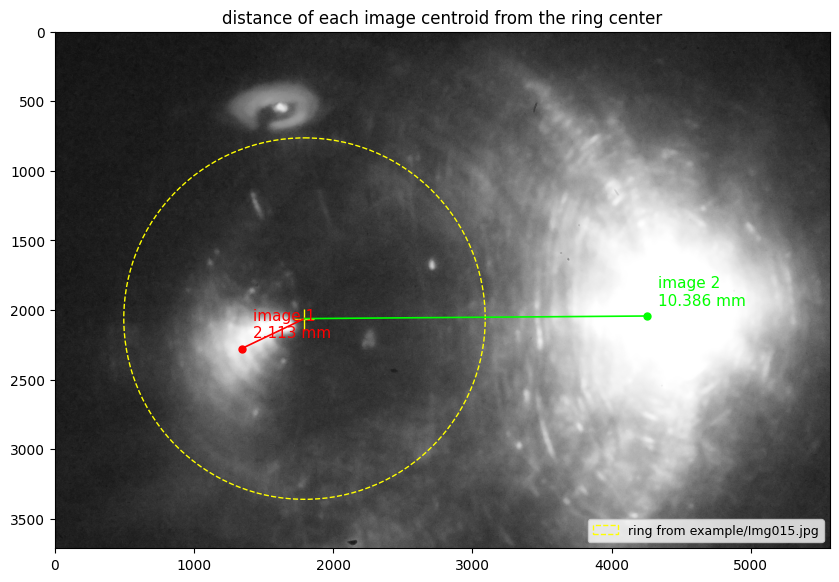

Ring center (from example/Img015.jpg): (7.5700, 8.7021) mm

Image 1: distance from ring center = 501 ± 34 px = 2.1133 ± 0.1451 mm   (0.386 x ring radius, at 154.5 deg)
Image 2: distance from ring center = 2461 ± 31 px = 10.3861 ± 0.1298 mm   (1.895 x ring radius, at 359.6 deg)

Separation between the two images = 12.3328 mm; angle between them as seen from the ring center = 154.9 deg


In [16]:
rcx, rcy, rerr = ring['cx'], ring['cy'], ring['err_center_px']
for m in images:
    dx, dy = m['cx'] - rcx, m['cy'] - rcy
    m['dist_px'] = float(np.hypot(dx, dy))
    m['angle_deg'] = float(np.degrees(np.arctan2(dy, dx)) % 360)
    shift = max(abs(np.hypot(x - rcx, y - rcy) - m['dist_px']) for x, y in m['centroid_alt'])
    m['dist_err_px'] = float(np.hypot(rerr, shift))

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(stretch(dbl_gray), cmap='gray')
ax.add_patch(plt.Circle((rcx, rcy), ring['r_px'], fill=False, color='yellow', lw=1, ls='--',
                        label=f'ring from {RING_IMAGE_PATH}'))
ax.plot(rcx, rcy, '+', color='yellow', ms=14)
cols = ['red', 'lime', 'orange', 'magenta']
for i, m in enumerate(images, start=1):
    col = cols[(i - 1) % len(cols)]
    ax.plot([rcx, m['cx']], [rcy, m['cy']], '-', color=col, lw=1.2)
    ax.plot(m['cx'], m['cy'], 'o', color=col, ms=5)
    ax.annotate(f"image {i}\n{m['dist_px']*PIXEL_SCALE:.3f} {UNIT}", (m['cx'], m['cy']), color=col,
                fontsize=11, xytext=(8, 8), textcoords='offset points')
ax.set_xlim(0, dbl_gray.shape[1]); ax.set_ylim(dbl_gray.shape[0], 0)
ax.legend(loc='lower right', fontsize=9)
ax.set_title('distance of each image centroid from the ring center')
plt.show()

print(f"Ring center (from {RING_IMAGE_PATH}): ({rcx*PIXEL_SCALE:.4f}, {rcy*PIXEL_SCALE:.4f}) {UNIT}\n")
for i, m in enumerate(images, start=1):
    print(f"Image {i}: distance from ring center = {m['dist_px']:.0f} ± {m['dist_err_px']:.0f} px"
          f" = {m['dist_px']*PIXEL_SCALE:.4f} ± {m['dist_err_px']*PIXEL_SCALE:.4f} {UNIT}"
          f"   ({m['dist_px'] / ring['r_px']:.3f} x ring radius, at {m['angle_deg']:.1f} deg)")
if len(images) == 2:
    sep = np.hypot(images[0]['cx'] - images[1]['cx'], images[0]['cy'] - images[1]['cy'])
    angle_between = abs((images[0]['angle_deg'] - images[1]['angle_deg'] + 180) % 360 - 180)
    print(f"\nSeparation between the two images = {sep*PIXEL_SCALE:.4f} {UNIT}; "
          f"angle between them as seen from the ring center = {angle_between:.1f} deg")

## 6. Summary of results

In [17]:
print(f"Pixel scale: {PIXEL_SCALE*1000:.3f} µm/px\n")
print(f"Ring picture: {RING_IMAGE_PATH}")
print(f"  Ring center:   x = {ring['cx']*PIXEL_SCALE:.4f} {UNIT},  y = {ring['cy']*PIXEL_SCALE:.4f} {UNIT}"
      f"   (± {ring['err_center_px']*PIXEL_SCALE:.4f} {UNIT})")
print(f"  Ring radius:   {ring['r_px']*PIXEL_SCALE:.4f} ± {ring['err_r_px']*PIXEL_SCALE:.4f} {UNIT}")
print(f"  Ring diameter: {2*ring['r_px']*PIXEL_SCALE:.4f} ± {2*ring['err_r_px']*PIXEL_SCALE:.4f} {UNIT}")
print(f"  Ring width:    {(ring['r_out_px'] - ring['r_in_px'])*PIXEL_SCALE:.4f} {UNIT} (half max)\n")
print(f"Double-image picture: {DOUBLE_IMAGES_PATH}")
hdr = ['x', 'y', 'dist. to center', '±', 'intensity', '±', 'saturated px']
print(f"  {'':8s}" + "".join(f"{h:>16s}" for h in hdr))
print(f"  {'':8s}" + "".join(f"{u:>16s}" for u in [f'({UNIT})'] * 4 + ['', '', '']))
for i, m in enumerate(images, start=1):
    vals = [f"{m['cx']*PIXEL_SCALE:.3f}", f"{m['cy']*PIXEL_SCALE:.3f}",
            f"{m['dist_px']*PIXEL_SCALE:.4f}", f"{m['dist_err_px']*PIXEL_SCALE:.4f}",
            f"{m['flux']:.1f}", f"{m['flux_err']:.1f}", f"{m['n_saturated']}"]
    print(f"  image {i:<2d}" + "".join(f"{v:>16s}" for v in vals))
if len(images) == 2:
    print(f"\n  Intensity ratio (image 1 / image 2) = {ratio:.3f} ± {ratio_err:.3f}")
    if any(m['n_saturated'] for m in images):
        print("  (an image contains saturated pixels, so its intensity -- and this ratio -- is a limit)")

Pixel scale: 4.221 µm/px

Ring picture: example/Img015.jpg
  Ring center:   x = 7.5700 mm,  y = 8.7021 mm   (± 0.0022 mm)
  Ring radius:   5.4798 ± 0.0016 mm
  Ring diameter: 10.9595 ± 0.0032 mm
  Ring width:    0.8589 mm (half max)

Double-image picture: example/Img021.jpg
                         x               y dist. to center               ±       intensity               ±    saturated px
                      (mm)            (mm)            (mm)            (mm)                                                
  image 1            5.663           9.612          2.1133          0.1451        188655.4         45218.0           16761
  image 2           17.956           8.623         10.3861          0.1298       2536239.2        444429.3          867033

  Intensity ratio (image 1 / image 2) = 0.074 ± 0.006
  (an image contains saturated pixels, so its intensity -- and this ratio -- is a limit)
